In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from keras.datasets import mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()

# Checking train dataset

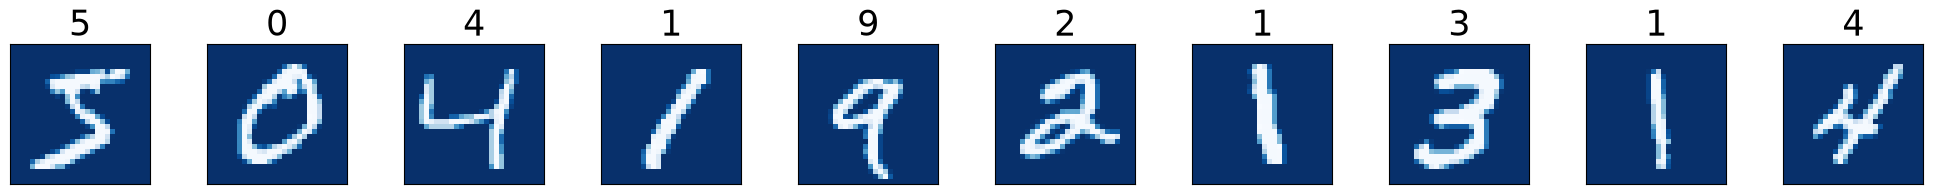

In [3]:
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(10):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    ax.imshow(train_x[idx], cmap='Blues_r')
    ax.set_title(str(train_y[idx]),fontsize=25)

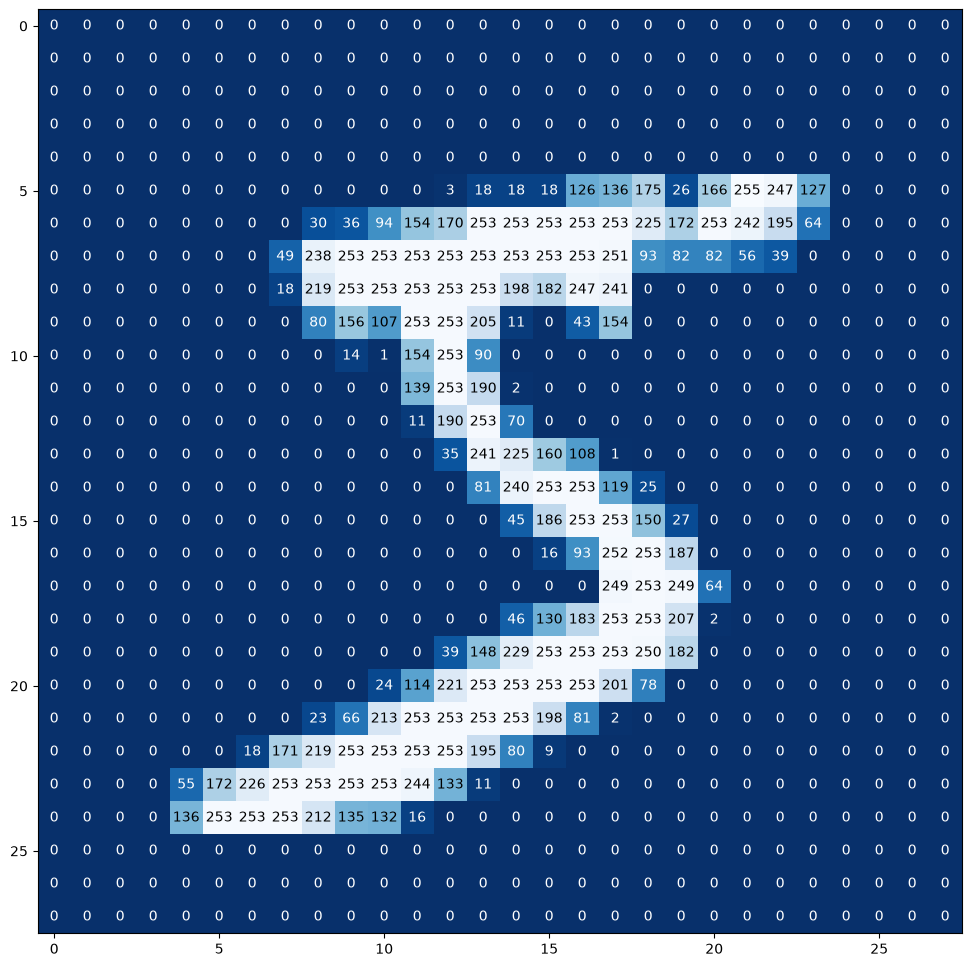

In [4]:
img = train_x[0]

fig = plt.figure(figsize = (12,12)) 
ax = fig.add_subplot(111)
ax.imshow(img, cmap='Blues_r')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')

In [5]:
# Reshape to 2D data
train_x = train_x.reshape(train_x.shape[0], -1)
print(train_x.shape)

sample_size = 5000
# Use only the top 1000 data for training
train_x = pd.DataFrame(train_x[:sample_size, :])
train_y = train_y[:sample_size]

(60000, 784)


In [6]:
# PCA
# PCA is the most representative method of dimensionality reduction.This is a method of re-axis 
# of multidimensional data in the direction of large variance. The greater the dependence between 
# variables, the smaller the principal component can represent the original data. However, since 
# it is assumed that each feature follows a normal distribution, it is not appropriate to apply a
# variable with a distorted distribution to PCA.

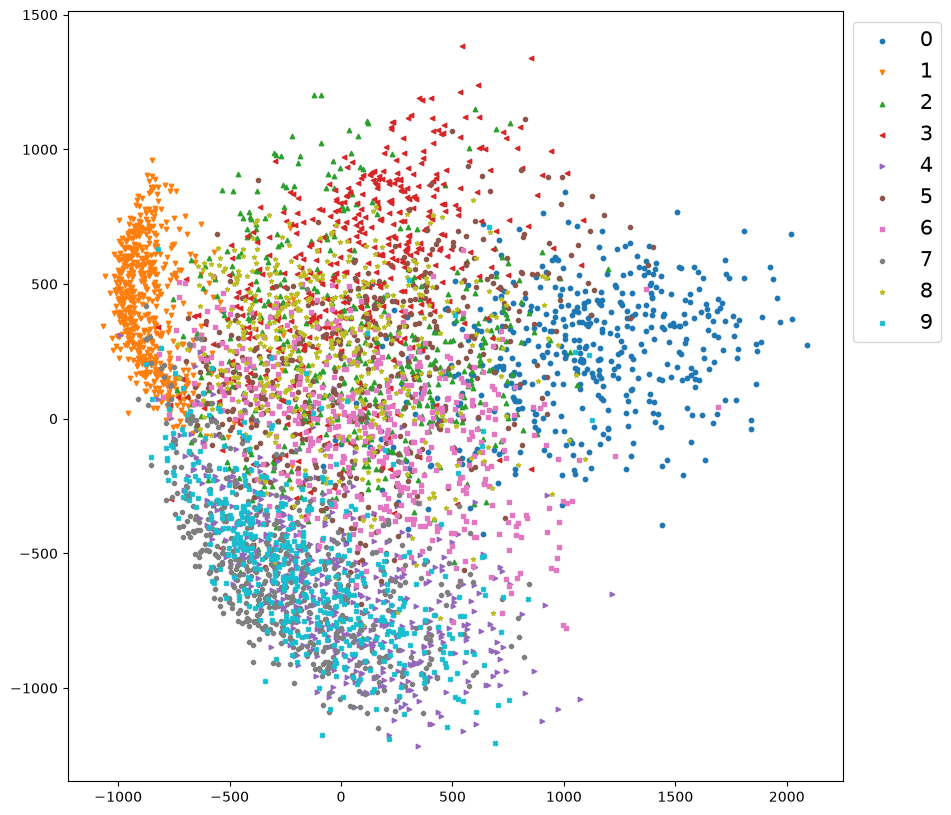

In [7]:
from sklearn.decomposition import PCA

pca = PCA()
x_pca = pca.fit_transform(train_x)
markers=['o','v','^','<','>','8','s','P','*','X']
# plot in 2D by class
plt.figure(figsize=(10,10))
for i,marker in enumerate(markers):
    mask = train_y == i
    plt.scatter(x_pca[mask, 0], x_pca[mask, 1], label=i, s=10, alpha=1,marker=marker)
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left',fontsize=15)

In [8]:
# Truncated SVD
# Truncated SVD is a method of extracting and decomposing only the upper part of the diagonal 
# elements in the sigma matrix, that is, the upper part of the singular values. With this 
# decomposition, the original matrix cannot be accurately restored because it artificially decomposes 
# U∑VT of smaller dimensions. However, despite the data information being compressed and decomposed,
# it is possible to approximate the original matrix to a considerable degree.

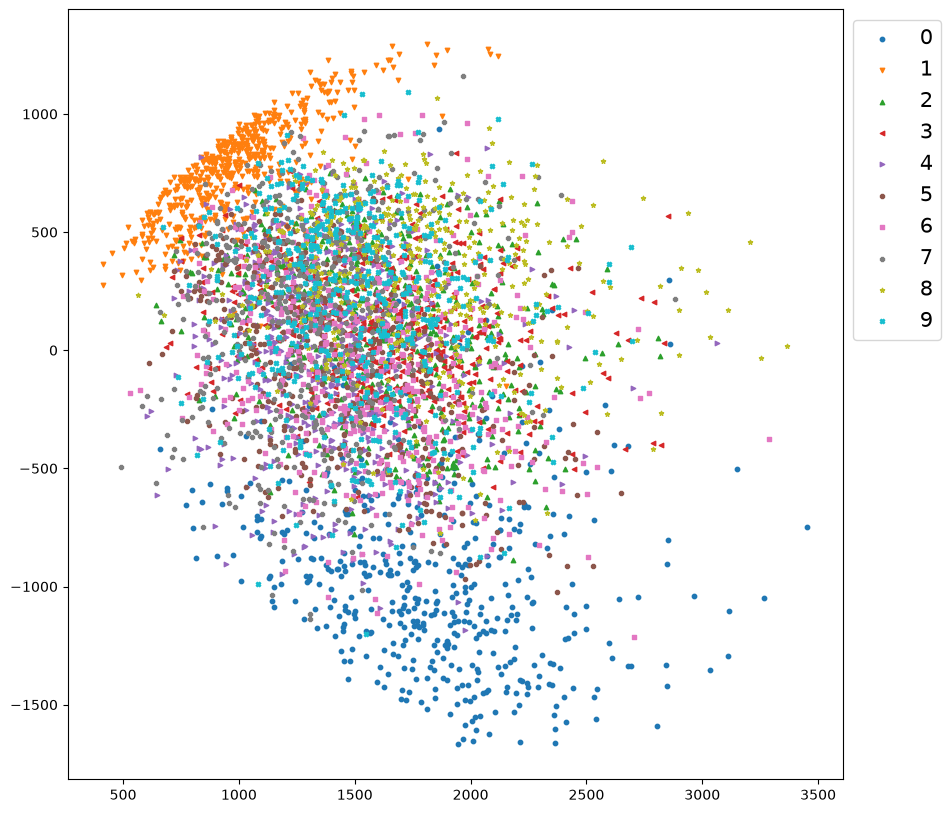

In [9]:
from sklearn.decomposition import TruncatedSVD

tsvd = TruncatedSVD()
x_tsvd = tsvd.fit_transform(train_x)
markers=['o','v','^','<','>','8','s','P','*','X']
# plot in 2D by class
plt.figure(figsize=(10,10))
for i,marker in enumerate(markers):
    
    mask = train_y == i
    plt.scatter(x_tsvd[mask, 0], x_tsvd[mask, 1], label=i, s=10, alpha=1,marker=marker)
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left',fontsize=15)

In [10]:
# NMF
# NMF is a variant of the Low-Rank Approximation method like SVD. However, it must be guaranteed 
# that the values ​​of all elements in the source matrix are positive. NMF decomposes a matrix 
# into W and H matrices. The W matrix indicates how well the values ​​of the latent elements 
# correspond to the source matrix. The H matrix represents how this latent element is composed of 
# sour features.

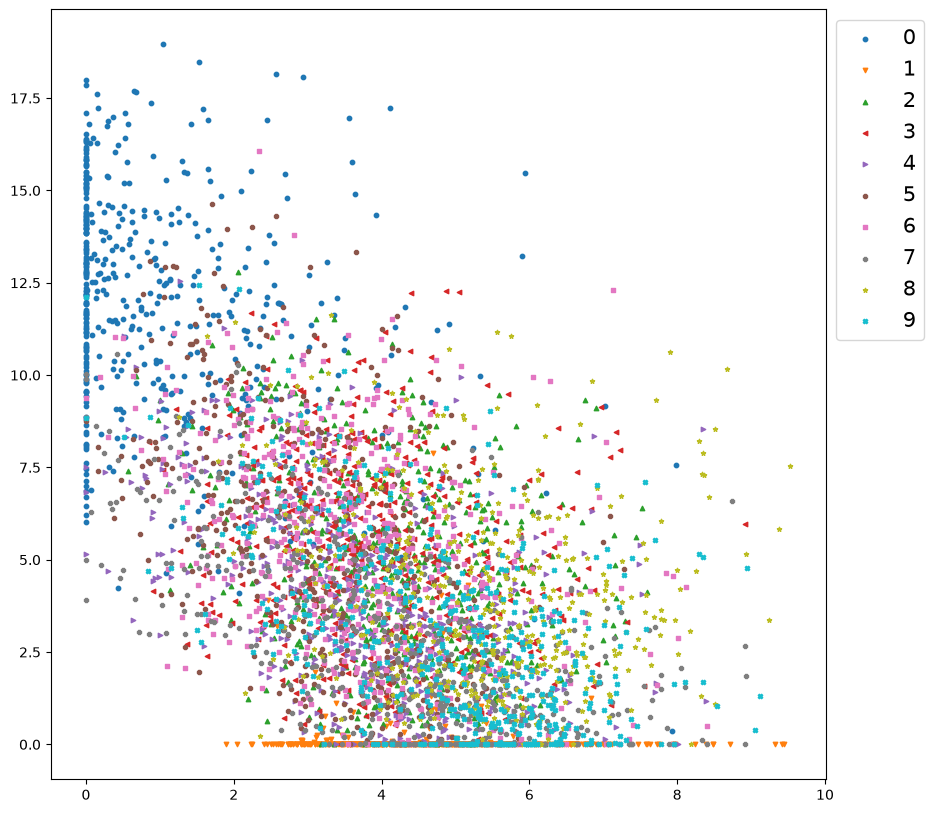

In [11]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=2, init='random', random_state=0)
x_nmf = nmf.fit_transform(train_x)
markers=['o','v','^','<','>','8','s','P','*','X']
# plot in 2D by class
plt.figure(figsize=(10,10))
for i,marker in enumerate(markers):
    mask = train_y == i
    plt.scatter(x_nmf[mask, 0], x_nmf[mask, 1], label=i, s=10, alpha=1,marker=marker)
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left',fontsize=15)

In [12]:
# LDA
# LDA is a method of dimensionality reduction in the classification problem of supervised learning. 
# It finds a low-dimensional feature space that can classify the training data well, and reduces the
# dimensionality by projecting the original features into that space.

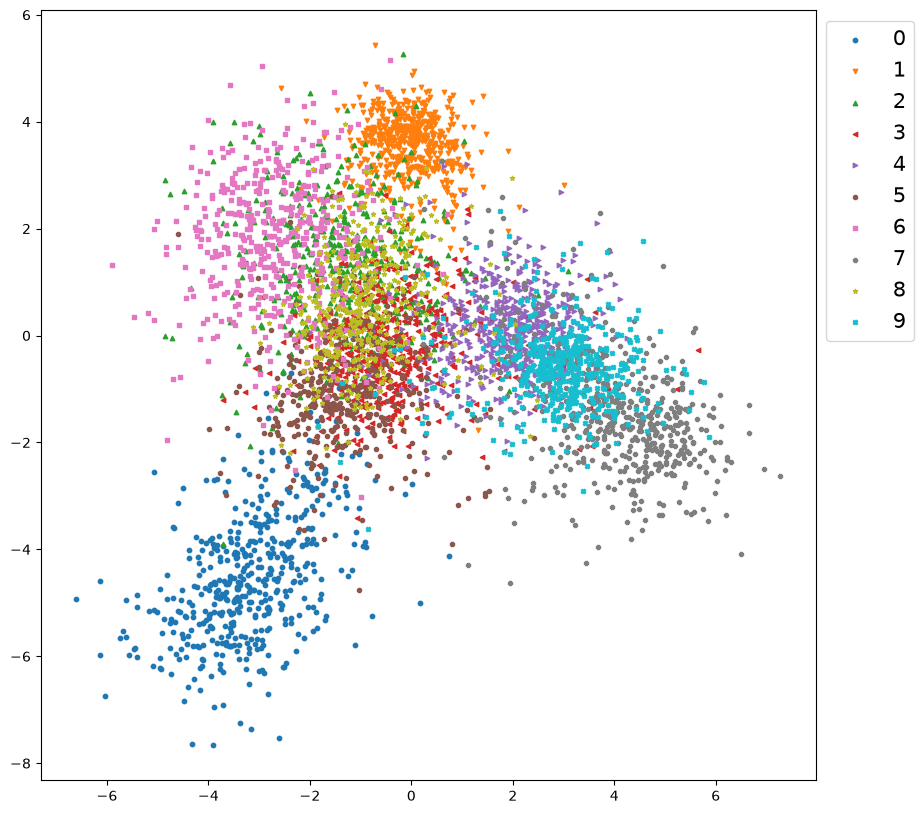

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)
x_lda = lda.fit_transform(train_x, train_y)

plt.figure(figsize=(10,10))
for i,marker in enumerate(markers):
    mask = train_y == i
    plt.scatter(x_lda[mask, 0], x_lda[mask, 1], label=i, s=10, alpha=1,marker=marker)
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left',fontsize=15)

In [14]:
# t-SNE
# t-SNE is often used for visualization purposes by compressing data on a two-dimensional plane. 
# Points that are close to the original feature space are also expressed in a two-dimensional plane 
# after compression. Since the nonlinear relationship can be identified, the model performance can 
# be improved by adding the compression results expressed by these t-SNEs to the original features. 
# However, since the computation cost is high, it is not suitable for compression exceeding two or 
# three dimensions.

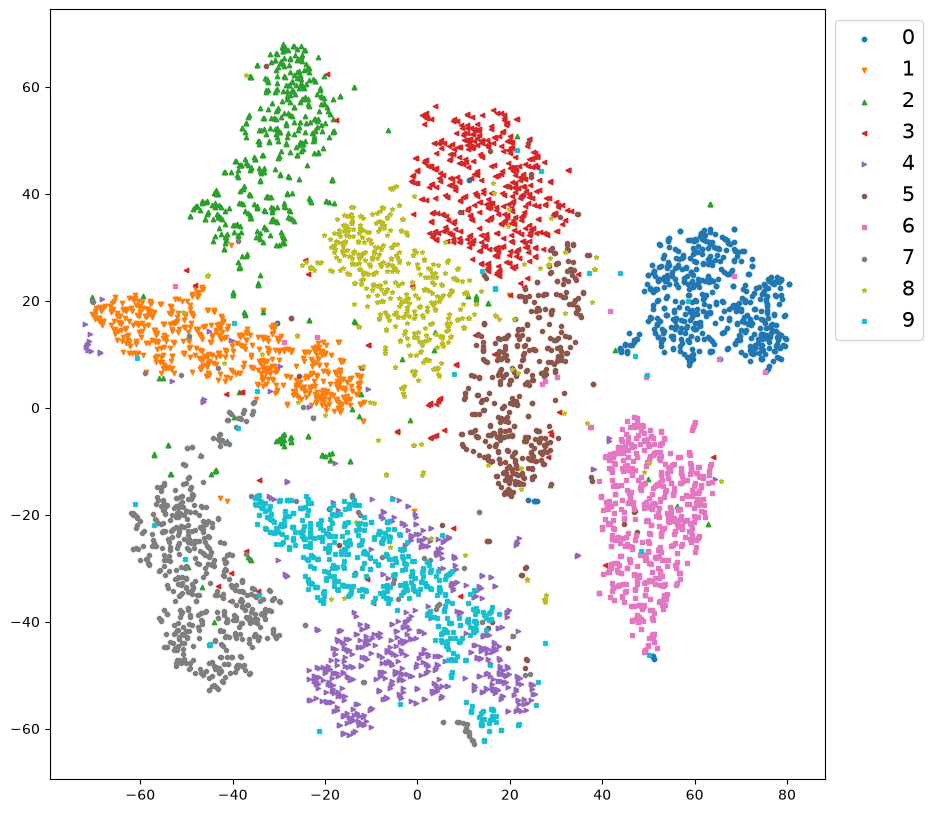

In [15]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
x_tsne = tsne.fit_transform(train_x)

plt.figure(figsize=(10,10))
for i,marker in enumerate(markers):
    mask = train_y == i
    plt.scatter(x_tsne[mask, 0], x_tsne[mask, 1], label=i, s=10, alpha=1,marker=marker)
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left',fontsize=15)

In [16]:
# UMAP
# UMAP (Uniform Manifold Approximation and Projection), which is faster than t-SNE and separates the 
# data space well, has been proposed for nonlinear dimensionality reduction. In other words, it can 
# process very large datasets quickly and is suitable for sparse matrix data. Furthermore, compared to
# t-SNE, it has the advantage of being able to embed immediately when new data comes in from other 
# machine learning models.

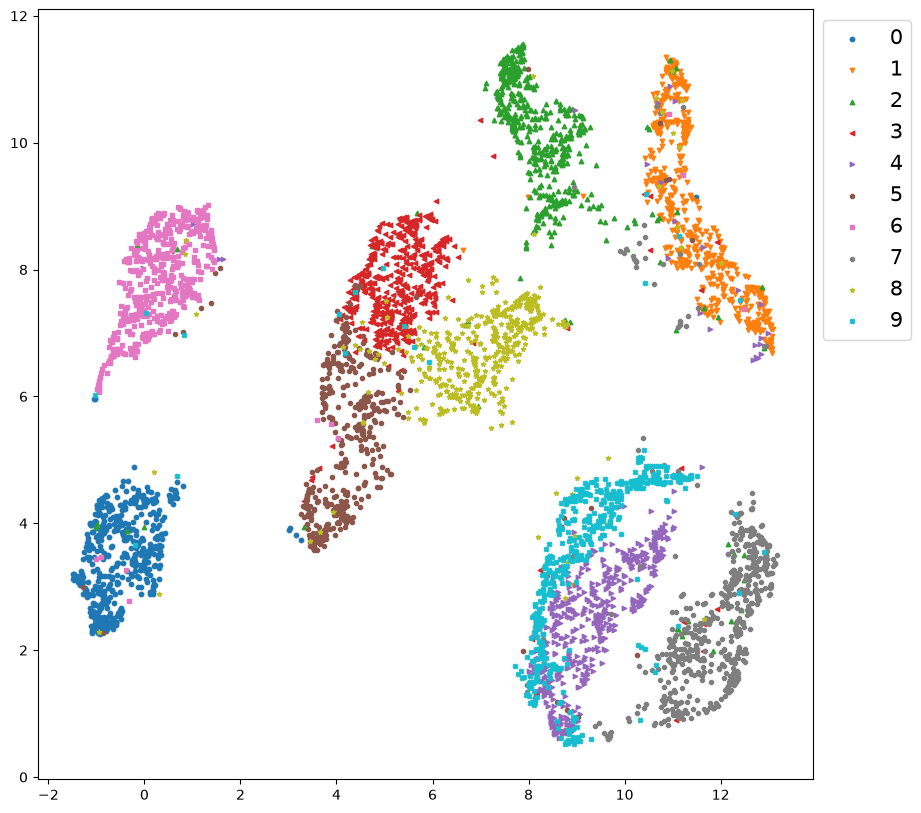

In [17]:
import umap

um = umap.UMAP()
x_umap = um.fit_transform(train_x)

plt.figure(figsize=(10,10))
for i,marker in enumerate(markers):
    mask = train_y == i
    plt.scatter(x_umap[mask, 0], x_umap[mask, 1], label=i, s=10, alpha=1,marker=marker)
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left',fontsize=15)

In [18]:
# UMAP connectivity plot
# Ref: https://umap-learn.readthedocs.io

C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than

<Axes: >

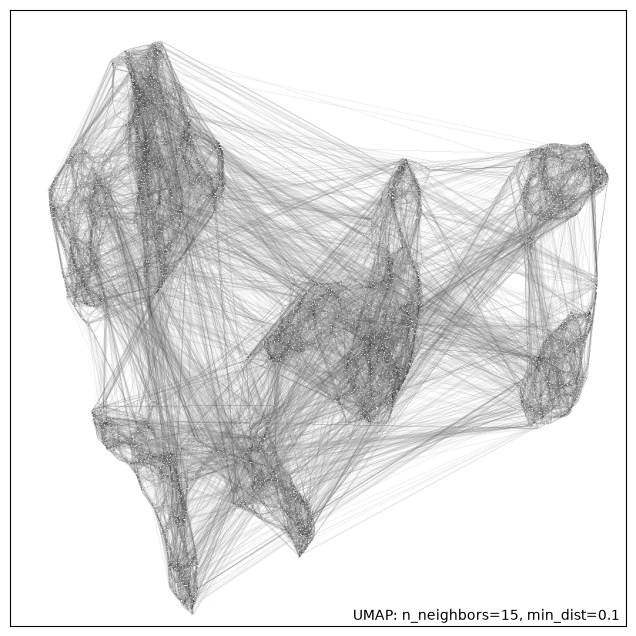

In [19]:
import umap.plot
mapper = umap.UMAP().fit(train_x)
umap.plot.connectivity(mapper, show_points=True)

<Axes: >

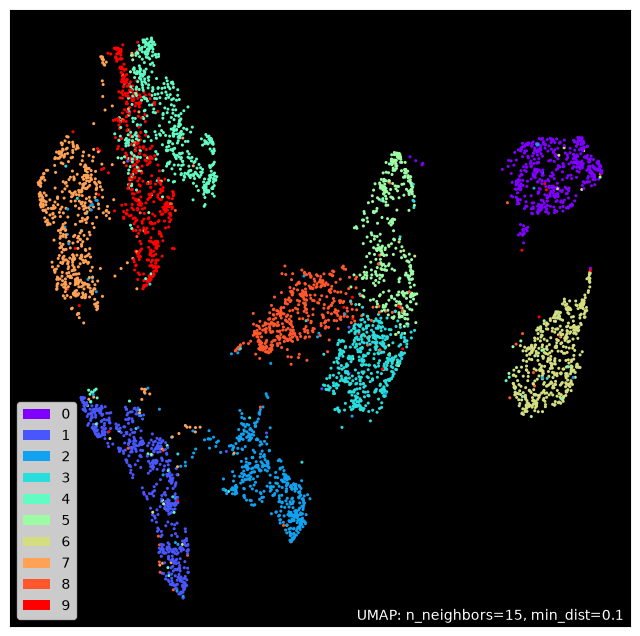

In [20]:
# Another UMAP plot
umap.plot.points(mapper, labels=train_y, theme='fire')

C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<class 'numpy.ndarray'>


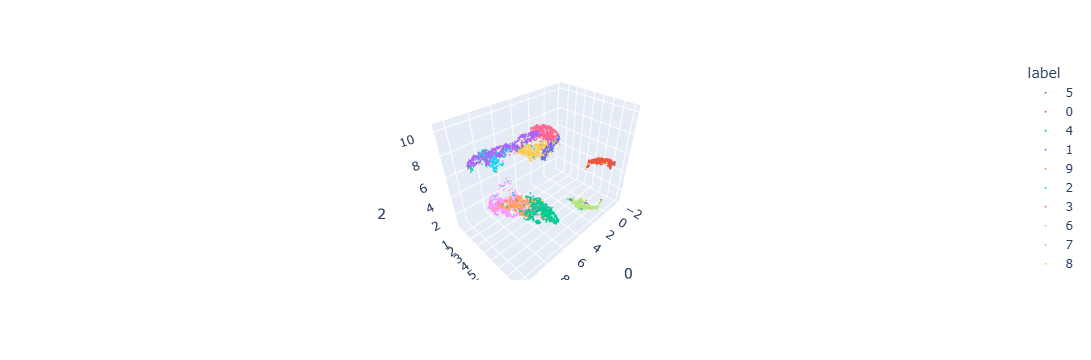

In [21]:
# UMAP 3D plot
import plotly
import plotly.express as px
from umap import UMAP

umap_3d = UMAP(n_components=3, init='random', random_state=0)
x_umap = umap_3d.fit_transform(train_x)
umap_df = pd.DataFrame(x_umap)
train_y_sr = pd.Series(train_y,name='label')
print(type(x_umap))
new_df = pd.concat([umap_df,train_y_sr],axis=1)
fig = px.scatter_3d(
    new_df, x=0, y=1, z=2,
    color='label', labels={'color': 'number'}
)
fig.update_traces(marker_size=1)
fig.show()